In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
left_img = cv2.imread("left.jpg", cv2.IMREAD_GRAYSCALE)
right_img = cv2.imread("right.jpg", cv2.IMREAD_GRAYSCALE)

In [3]:
if left_img is None or right_img is None:
    print("Error: Could not load left.jpg or right.jpg")
    exit()

In [4]:
if left_img.shape != right_img.shape:
    right_img = cv2.resize(right_img, (left_img.shape[1], left_img.shape[0]))

In [5]:
stereo = cv2.StereoBM_create(
    numDisparities=16 * 5,
    blockSize=15             
)

In [6]:
disparity = stereo.compute(left_img, right_img)
disparity = disparity.astype(np.float32) / 16.0
disparity[disparity <= 0] = 0.1

In [7]:
baseline = 65
focal_length = 400

In [8]:
depth = (baseline * focal_length) / disparity

In [9]:
disparity_display = cv2.normalize(
    disparity, None, 0, 255, cv2.NORM_MINMAX
)
disparity_display = np.uint8(disparity_display)

In [10]:
depth_display = cv2.normalize(
    depth, None, 0, 255, cv2.NORM_MINMAX
)
depth_display = np.uint8(depth_display)

In [12]:
depth_color = cv2.applyColorMap(depth_display, cv2.COLORMAP_JET)

In [13]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

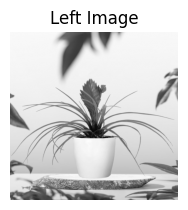

In [14]:
plt.subplot(2, 2, 1)
plt.imshow(left_img, cmap='gray')
plt.title("Left Image")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

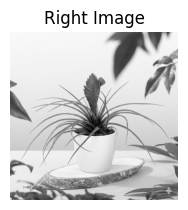

In [15]:
plt.subplot(2, 2, 2)
plt.imshow(right_img, cmap='gray')
plt.title("Right Image")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

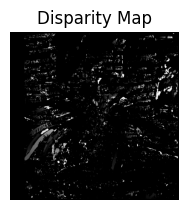

In [16]:
plt.subplot(2, 2, 3)
plt.imshow(disparity_display, cmap='gray')
plt.title("Disparity Map")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

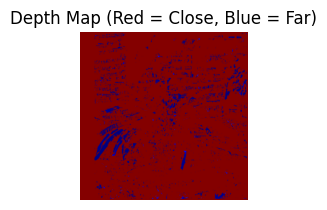

In [17]:
plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(depth_color, cv2.COLOR_BGR2RGB))
plt.title("Depth Map (Red = Close, Blue = Far)")
plt.axis("off")

In [18]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [19]:
cv2.imwrite("disparity_map.jpg", disparity_display)
cv2.imwrite("depth_map.jpg", depth_color)

True

In [21]:
print("Depth estimation completed.")
print("Saved:")
print(" - disparity_map.jpg")
print(" - depth_map.jpg")

Depth estimation completed.
Saved:
 - disparity_map.jpg
 - depth_map.jpg
